# EDA Supplementary Notebook
This notebook was used to create the **Exploratory Data Analysis** section of the paper.

In [21]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

conn = duckdb.connect('../lakehouse_db/aki_lakehouse.db', read_only=True)
print('Connected successfully.')

Connected successfully.


---
## 1. Cohort Demographics

### 1.1 Overall cohort size

In [2]:
cohort = conn.execute('''
    SELECT
        COUNT(*)                AS total_hourly_rows,
        COUNT(DISTINCT stay_id) AS total_icu_stays,
        COUNT(DISTINCT patient_id) AS unique_patients
    FROM gold_hourly_clinical
''').df()
display(cohort)

,total_hourly_rows,total_icu_stays,unique_patients
0,2304561,72082,50573


### 1.2 Gender distribution

In [3]:
gender = conn.execute('''
    SELECT
        gender,
        COUNT(DISTINCT stay_id)                                  AS stays,
        ROUND(COUNT(DISTINCT stay_id) * 100.0
              / SUM(COUNT(DISTINCT stay_id)) OVER (), 1)        AS pct
    FROM gold_hourly_clinical
    GROUP BY gender
    ORDER BY stays DESC
''').df()
display(gender)

,gender,stays,pct
0,male,40172,55.7
1,female,31910,44.3


### 1.3 Age statistics


In [4]:
age_stats = conn.execute('''
    SELECT
        ROUND(AVG(age), 1)                                              AS mean_age,
        ROUND(STDDEV(age), 1)                                           AS std_age,
        MIN(age)                                                        AS min_age,
        MAX(age)                                                        AS max_age,
        ROUND(PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY age), 0)    AS p25,
        ROUND(PERCENTILE_CONT(0.50) WITHIN GROUP (ORDER BY age), 0)    AS median,
        ROUND(PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY age), 0)    AS p75
    FROM (SELECT DISTINCT ON (stay_id) stay_id, age FROM gold_hourly_clinical)
''').df()
display(age_stats)

,mean_age,std_age,min_age,max_age,p25,median,p75
0,64.6,16.8,18,90,54.0,66.0,77.0


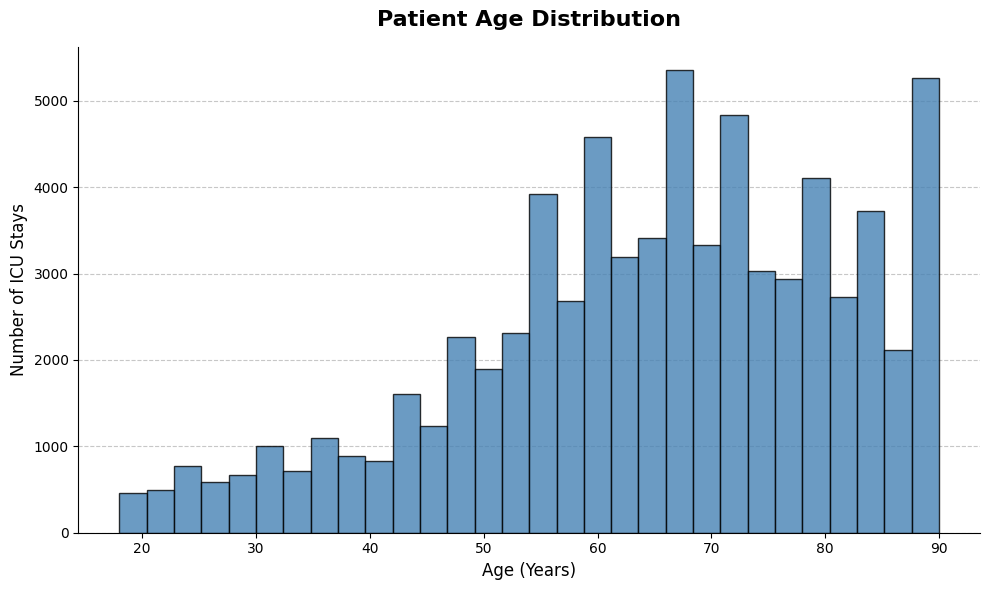

In [22]:
age_data = conn.execute('''
    SELECT DISTINCT ON (stay_id) stay_id, age 
    FROM gold_hourly_clinical
''').df()

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(age_data['age'], bins=30, color='steelblue', edgecolor='black', alpha=0.8)

ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_title('Patient Age Distribution', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Age (Years)', fontsize=12)
ax.set_ylabel('Number of ICU Stays', fontsize=12)

plt.tight_layout()
plt.show()


### 1.4 Admission weight statistics

In [5]:
weight_stats = conn.execute('''
    SELECT
        COUNT(DISTINCT stay_id)                                         AS total_stays,
        COUNT(DISTINCT CASE WHEN admission_weight IS NOT NULL
                            THEN stay_id END)                           AS stays_with_weight,
        COUNT(DISTINCT CASE WHEN admission_weight IS NULL
                            THEN stay_id END)                           AS stays_missing_weight,
        ROUND(ROUND(COUNT(DISTINCT CASE WHEN admission_weight IS NULL
                            THEN stay_id END), 0) * 100.0
              / COUNT(DISTINCT stay_id), 1)                            AS pct_missing,
        ROUND(AVG(admission_weight), 1)                                 AS mean_weight_kg,
        ROUND(STDDEV(admission_weight), 1)                              AS std_weight_kg,
        ROUND(PERCENTILE_CONT(0.50) WITHIN GROUP
              (ORDER BY admission_weight), 1)                           AS median_weight_kg
    FROM (SELECT DISTINCT ON (stay_id) stay_id, admission_weight
          FROM gold_hourly_clinical)
''').df()
display(weight_stats)

,total_stays,stays_with_weight,stays_missing_weight,pct_missing,mean_weight_kg,std_weight_kg,median_weight_kg
0,72082,66946,5136,7.1,81.1,34.2,77.8


### 1.5 Comorbidity prevalence

In [6]:
comorbidities = conn.execute('''
    WITH stay_level AS (
        SELECT DISTINCT ON (stay_id)
            stay_id,
            history_ckd,
            history_diabetes,
            history_chf,
            history_sepsis
        FROM gold_hourly_clinical
    )
    SELECT
        COUNT(*)                                            AS total_stays,
        SUM(history_ckd)                                   AS ckd_n,
        ROUND(AVG(history_ckd) * 100, 1)                  AS ckd_pct,
        SUM(history_diabetes)                              AS diabetes_n,
        ROUND(AVG(history_diabetes) * 100, 1)             AS diabetes_pct,
        SUM(history_chf)                                   AS chf_n,
        ROUND(AVG(history_chf) * 100, 1)                  AS chf_pct,
        SUM(history_sepsis)                                AS sepsis_n,
        ROUND(AVG(history_sepsis) * 100, 1)               AS sepsis_pct
    FROM stay_level
''').df()
display(comorbidities)

,total_stays,ckd_n,ckd_pct,diabetes_n,diabetes_pct,chf_n,chf_pct,sepsis_n,sepsis_pct
0,72082,20409.0,28.3,17796.0,24.7,25416.0,35.3,0.0,0.0


---
## 2. AKI Prevalence and Target Distribution

### 2.1 Stay-level AKI prevalence

In [7]:
aki_stay = conn.execute('''
    WITH stay_level AS (
        SELECT stay_id, MAX(aki_within_6h) AS developed_aki
        FROM gold_hourly_clinical
        GROUP BY stay_id
    )
    SELECT
        developed_aki,
        COUNT(*)                                                    AS stays,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 1)        AS pct
    FROM stay_level
    GROUP BY developed_aki
    ORDER BY developed_aki
''').df()
display(aki_stay)

,developed_aki,stays,pct
0,0,32778,45.5
1,1,39304,54.5


### 2.2 Hourly-level target distribution

In [8]:
target_dist = conn.execute('''
    SELECT
        aki_within_6h       AS label,
        COUNT(*)            AS samples,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS pct
    FROM gold_hourly_clinical
    GROUP BY aki_within_6h
    ORDER BY aki_within_6h
''').df()
display(target_dist)

,label,samples,pct
0,0,2083777,90.42
1,1,220784,9.58


### 2.3 Class imbalance ratio

In [9]:
ratio = conn.execute('''
    SELECT
        ROUND(
            SUM(CASE WHEN aki_within_6h = 0 THEN 1 ELSE 0 END) * 1.0
            / NULLIF(SUM(CASE WHEN aki_within_6h = 1 THEN 1 ELSE 0 END), 0)
        , 2) AS neg_to_pos_ratio
    FROM gold_hourly_clinical
''').df()
display(ratio)

,neg_to_pos_ratio
0,9.44


---
## 3. Feature Distributions and Statistical Summaries

### 3.1 Core feature summary statistics

In [10]:
feature_stats = conn.execute('''
    SELECT
        -- Creatinine (mg/dL)
        ROUND(AVG(creatinine), 2)                                                       AS cr_mean,
        ROUND(STDDEV(creatinine), 2)                                                    AS cr_sd,
        ROUND(PERCENTILE_CONT(0.5)  WITHIN GROUP (ORDER BY creatinine), 2)             AS cr_median,
        ROUND(PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY creatinine), 2)             AS cr_p25,
        ROUND(PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY creatinine), 2)             AS cr_p75,

        -- Blood Urea Nitrogen (mg/dL)
        ROUND(AVG(bun), 2)                                                              AS bun_mean,
        ROUND(STDDEV(bun), 2)                                                           AS bun_sd,
        ROUND(PERCENTILE_CONT(0.5)  WITHIN GROUP (ORDER BY bun), 2)                    AS bun_median,
        ROUND(PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY bun), 2)                    AS bun_p25,
        ROUND(PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY bun), 2)                    AS bun_p75,

        -- Heart Rate (bpm)
        ROUND(AVG(heart_rate), 2)                                                       AS hr_mean,
        ROUND(STDDEV(heart_rate), 2)                                                    AS hr_sd,
        ROUND(PERCENTILE_CONT(0.5)  WITHIN GROUP (ORDER BY heart_rate), 2)             AS hr_median,
        ROUND(PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY heart_rate), 2)             AS hr_p25,
        ROUND(PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY heart_rate), 2)             AS hr_p75,

        -- Mean Arterial Pressure (mmHg)
        ROUND(AVG(map), 2)                                                              AS map_mean,
        ROUND(STDDEV(map), 2)                                                           AS map_sd,
        ROUND(PERCENTILE_CONT(0.5)  WITHIN GROUP (ORDER BY map), 2)                    AS map_median,
        ROUND(PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY map), 2)                    AS map_p25,
        ROUND(PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY map), 2)                    AS map_p75,

        -- Urine Output (mL/hr)
        ROUND(AVG(uo_hourly), 2)                                                        AS uo_mean_ml,
        ROUND(STDDEV(uo_hourly), 2)                                                     AS uo_sd_ml,
        ROUND(PERCENTILE_CONT(0.5)  WITHIN GROUP (ORDER BY uo_hourly), 2)              AS uo_median_ml,
        ROUND(PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY uo_hourly), 2)              AS uo_p25_ml,
        ROUND(PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY uo_hourly), 2)              AS uo_p75_ml,

        -- Weight-Normalised Urine Output (mL/kg/hr)
        ROUND(AVG(uo_ml_kg_hr), 2)                                                      AS uo_rate_mean,
        ROUND(STDDEV(uo_ml_kg_hr), 2)                                                   AS uo_rate_sd,
        ROUND(PERCENTILE_CONT(0.5)  WITHIN GROUP (ORDER BY uo_ml_kg_hr), 2)            AS uo_rate_median,
        ROUND(PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY uo_ml_kg_hr), 2)            AS uo_rate_p25,
        ROUND(PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY uo_ml_kg_hr), 2)            AS uo_rate_p75
    FROM gold_hourly_clinical
''').df()

# Transpose for readability: one row per feature
feature_stats_T = feature_stats.T.rename(columns={0: "value"})
feature_stats_T.index.name = "statistic"
display(feature_stats_T)

,value
statistic,
cr_mean,1.08
cr_sd,1.07
cr_median,0.80
cr_p25,0.60
cr_p75,1.10
bun_mean,15.17
bun_sd,3.26
bun_median,15.00
bun_p25,15.00


### 3.2 Outlier check: high-variance features

In [11]:
outliers = conn.execute('''
    SELECT
        MIN(heart_rate)         AS hr_min,
        MAX(heart_rate)         AS hr_max,
        MIN(uo_ml_kg_hr)        AS uo_rate_min,
        MAX(uo_ml_kg_hr)        AS uo_rate_max,
        COUNT(*) FILTER (WHERE heart_rate > 300)        AS hr_extreme_outliers,
        COUNT(*) FILTER (WHERE uo_ml_kg_hr > 50)        AS uo_rate_extreme_outliers
    FROM gold_hourly_clinical
''').df()
display(outliers)

,hr_min,hr_max,uo_rate_min,uo_rate_max,hr_extreme_outliers,uo_rate_extreme_outliers
0,20.0,300.0,0.0,2000.0,0,1139


---
## 4. Feature–Target Stratification

### 4.1 Mean features by AKI label

In [12]:
stratified = conn.execute('''
    SELECT
        aki_within_6h                                       AS label,
        COUNT(*)                                            AS n,
        ROUND(AVG(creatinine), 3)                          AS mean_creatinine,
        ROUND(AVG(bun), 2)                                 AS mean_bun,
        ROUND(AVG(heart_rate), 2)                          AS mean_heart_rate,
        ROUND(AVG(map), 2)                                 AS mean_map,
        ROUND(AVG(uo_ml_kg_hr), 3)                         AS mean_uo_rate,
        ROUND(AVG(age), 1)                                 AS mean_age
    FROM gold_hourly_clinical
    GROUP BY aki_within_6h
    ORDER BY aki_within_6h
''').df()
display(stratified)

,label,n,mean_creatinine,mean_bun,mean_heart_rate,mean_map,mean_uo_rate,mean_age
0,0,2083777,1.033,15.16,84.19,84.43,1.331,62.6
1,1,220784,1.493,15.22,84.95,82.59,0.371,66.9


### 4.2 Creatinine relative elevation (positive vs negative class)

In [13]:
cr_lift = conn.execute('''
    WITH means AS (
        SELECT
            AVG(creatinine) FILTER (WHERE aki_within_6h = 1) AS cr_positive,
            AVG(creatinine) FILTER (WHERE aki_within_6h = 0) AS cr_negative
        FROM gold_hourly_clinical
    )
    SELECT
        ROUND(cr_positive, 3)                                   AS mean_cr_positive,
        ROUND(cr_negative, 3)                                   AS mean_cr_negative,
        ROUND((cr_positive - cr_negative) / cr_negative * 100, 1) AS relative_elevation_pct
    FROM means
''').df()
display(cr_lift)

,mean_cr_positive,mean_cr_negative,relative_elevation_pct
0,1.493,1.033,44.5


### 4.3 Urine output ratio (negative vs positive class)

In [14]:
uo_ratio = conn.execute('''
    WITH means AS (
        SELECT
            AVG(uo_ml_kg_hr) FILTER (WHERE aki_within_6h = 0) AS uo_negative,
            AVG(uo_ml_kg_hr) FILTER (WHERE aki_within_6h = 1) AS uo_positive
        FROM gold_hourly_clinical
    )
    SELECT
        ROUND(uo_negative, 3)                           AS mean_uo_rate_negative,
        ROUND(uo_positive, 3)                           AS mean_uo_rate_positive,
        ROUND(uo_negative / NULLIF(uo_positive, 0), 2) AS fold_reduction
    FROM means
''').df()
display(uo_ratio)

,mean_uo_rate_negative,mean_uo_rate_positive,fold_reduction
0,1.331,0.371,3.58


### 4.4 Comorbidity rates stratified by AKI label

In [15]:
comorbidity_strat = conn.execute('''
    SELECT
        aki_within_6h                                   AS label,
        ROUND(AVG(history_ckd) * 100, 1)               AS ckd_pct,
        ROUND(AVG(history_diabetes) * 100, 1)          AS diabetes_pct,
        ROUND(AVG(history_chf) * 100, 1)               AS chf_pct,
        ROUND(AVG(history_sepsis) * 100, 1)            AS sepsis_pct
    FROM gold_hourly_clinical
    GROUP BY aki_within_6h
    ORDER BY aki_within_6h
''').df()
display(comorbidity_strat)

,label,ckd_pct,diabetes_pct,chf_pct,sepsis_pct
0,0,21.0,20.1,29.3,0.0
1,1,33.3,27.1,41.5,0.0


---
## 5. Data Staleness and Temporal Structure

### 5.1 Staleness statistics per feature

In [16]:
staleness = conn.execute('''
    SELECT
        ROUND(AVG(hours_since_last_cr), 2)                                          AS cr_mean_stale_h,
        ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY hours_since_last_cr), 1)  AS cr_median_stale_h,
        ROUND(AVG(hours_since_last_bun), 2)                                         AS bun_mean_stale_h,
        ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY hours_since_last_bun), 1) AS bun_median_stale_h,
        ROUND(AVG(hours_since_last_hr), 2)                                          AS hr_mean_stale_h,
        ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY hours_since_last_hr), 1)  AS hr_median_stale_h,
        ROUND(AVG(hours_since_last_map), 2)                                         AS map_mean_stale_h,
        ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY hours_since_last_map), 1) AS map_median_stale_h
    FROM gold_hourly_clinical
''').df()
display(staleness)

,cr_mean_stale_h,cr_median_stale_h,bun_mean_stale_h,bun_median_stale_h,hr_mean_stale_h,hr_median_stale_h,map_mean_stale_h,map_median_stale_h
0,14.29,8.0,47.9,48.0,0.87,0.0,20.05,24.0


### 5.2 ICU stay length distribution

In [17]:
stay_lengths = conn.execute('''
    SELECT
        ROUND(AVG(length_hours), 1)                                                     AS mean_hours,
        ROUND(STDDEV(length_hours), 1)                                                  AS std_hours,
        MIN(length_hours)                                                               AS min_hours,
        MAX(length_hours)                                                               AS max_hours,
        ROUND(PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY length_hours), 1)           AS p25_hours,
        ROUND(PERCENTILE_CONT(0.50) WITHIN GROUP (ORDER BY length_hours), 1)           AS median_hours,
        ROUND(PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY length_hours), 1)           AS p75_hours
    FROM (
        SELECT stay_id, MAX(hr_index) AS length_hours
        FROM gold_hourly_clinical
        GROUP BY stay_id
    )
''').df()
display(stay_lengths)

,mean_hours,std_hours,min_hours,max_hours,p25_hours,median_hours,p75_hours
0,31.0,40.8,0,769,9.0,20.0,37.0


### 5.3 Target leakage verification

In [18]:
leakage = conn.execute('''
    SELECT
        MAX(is_aki_now)     AS max_is_aki_now,
        SUM(is_aki_now)     AS sum_is_aki_now
    FROM gold_hourly_clinical
''').df()
print("Both values must be 0 (no leakage):")
display(leakage)

Both values must be 0 (no leakage):


,max_is_aki_now,sum_is_aki_now
0,0,0.0
